In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import emcee
import sys
import jetsimpy
import numpy as np
#import seaborn as sns
#import afterglowpy as grb
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from astropy.cosmology import Planck18 as cosmo
from astropy.time import Time
#from getdist import plots, MCSamples

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [4]:
day2sec = 24*3600

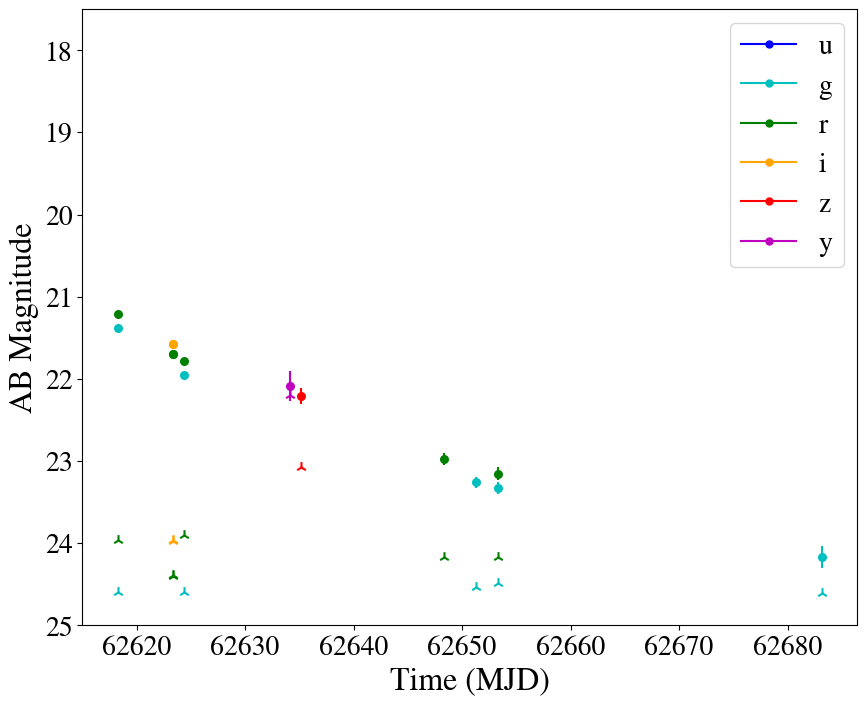

In [16]:
file_open = open('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
oa = pickle.load(file_open)
file_open.close()

one_oa = oa[5]

plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(10,8))

filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]

x_times = one_oa['time']
z_colors = one_oa['filt']
y_mags = one_oa['mags']
mags_lim = one_oa['mags_lim']
mags_err = one_oa['mags_err']

# plot pseudo observed light curve
for x, y, z, m, e in zip(x_times, y_mags, z_colors, mags_lim, mags_err):
    if y < m:
        plt.scatter(x, y, c=z, s=30)
        plt.errorbar(x, y, e, c=z, capsize=0)
        plt.scatter(x, m, c=z, marker='2', s=60)

plt.xlabel('Time (MJD)', fontsize=23)
plt.gca().invert_yaxis()
plt.ylabel('AB Magnitude', fontsize=23)
plt.ylim(25,17.5)

legend_elements_2 = list()

for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                    markerfacecolor=fcolor, markersize=5))
plt.legend(handles=legend_elements_2)
#plt.savefig('../figures/pseudo_obs_example.pdf', transparent=True, bbox_inches='tight')
plt.show()

In [5]:
dT = []

for o in oa:
    T0_true = Time(o['grb_time']).mjd
    T1 = min(np.array(o['time'])[np.array(o['mags'])<o['mags_lim']])
    
    dT.append(T1 - T0_true)

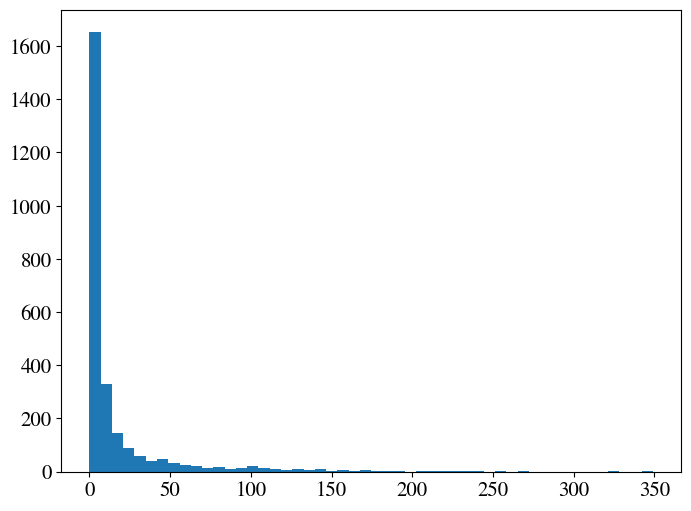

In [6]:
plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(8,6))
plt.hist(dT, bins=50);

In [17]:
def rescale_filters(times, mags, mags_err, filts):
    """
    Rescale magnitudes from all filters to the r-band, keeping array order.

    Parameters
    ----------
    times : array
        Observation times
    mags : array
        Observed magnitudes
    mags_err : array
        Magnitude uncertainties
    filts : array
        Filter names as colours: {'u':'b', 'g':'c', 'r':'g', 'i':'orange', 'z':'r', 'Y':'m'}

    Returns
    -------
    times : array
        Same as input
    mags_r : array
        Magnitudes rescaled to r-band
    mags_err : array
        Same errors, in original order
    """

    filters = ['b', 'c', 'g', 'orange', 'r', 'm']
    mean_nus = [840336134453781.4, 629326620516047.8, 482703137570394.2,
                397614314115308.1, 344530577088716.56, 298760145396604.1]

    # Map colour to frequency
    filt_to_nu = dict(zip(filters, mean_nus))

    # Find most common non-r filter to define spectral slope
    filt_obs = filts[filts != 'g']
    if len(filt_obs) == 0:
        return times, mags, mags_err

    unique, counts = np.unique(filt_obs, return_counts=True)
    filt_max = unique[np.argmax(counts)]
    nu_filtmax = filt_to_nu[filt_max]

    # Select data for fitting beta
    mask_r = filts == 'g'
    mask_fmax = filts == filt_max

    flux_r = mag_to_flux(mags[mask_r])
    flux_fmax = mag_to_flux(mags[mask_fmax])
    time_r = times[mask_r]
    time_fmax = times[mask_fmax]

    beta_vals = np.linspace(-0.6, -1.1, 10)
    dists = []

    for b in beta_vals:
        flux_rescaled = flux_fmax * (filt_to_nu['g'] / nu_filtmax) ** b
        dist = np.sum(np.sqrt((time_fmax[:, None] - time_r[None, :]) ** 2 +
                              (flux_rescaled[:, None] - flux_r[None, :]) ** 2))
        dists.append(dist)

    best_beta = beta_vals[np.argmin(dists)]

    # Rescale each point individually
    mags_r = []
    for mag, filt in zip(mags, filts):
        nu = filt_to_nu[filt]
        flux = mag_to_flux(mag)

        if filt != 'g':
            flux_rescaled = flux * (filt_to_nu['g'] / nu) ** best_beta
            mag_rescaled = flux_to_mag(flux_rescaled)
        else:
            mag_rescaled = mag

        mags_r.append(mag_rescaled)

    return times, np.array(mags_r), mags_err

In [18]:
def flux_to_mag(flux):
    """ Convert flux from milliJansky to AB Magnitude

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param flux: flux in milli-Jansky
    :return: mag: as the AB Magnitude
    """

    mag = -2.5 * np.log10(flux * 1.0e-26) - 48.6
    return mag


def mag_to_flux(mag):
    """ Convert flux from AB Magnitude to milliJansky

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param mag: as the AB Magnitude
    :return: flux: flux in milli-Jansky
    """

    flux = pow(10, (26 - (mag + 48.6) / 2.5))
    return flux


def model(t, nu, params):
    """ Model used to fit, implemented here in the afterglowpy package
    """

    P = dict(
            Eiso = 1e52,        # Core isotropic equivalent energy
            lf = 300,           # Core Lorentz factor
            theta_c = 0.1,      # half opening angle
            n0 = 1,             # ism number density
            A = 0,              # wind number density amplitude
            eps_e = 0.1,        # epsilon_e
            eps_b = 0.01,       # epsilon_b
            p = 2.17,           # electron power index
            theta_v = 0.0,      # viewing angle (rad)
            d = 474.33,         # distance (Mpc)
            z = 0.1,            # redshift
            s = 4)              # power-law jet slope (required for power-law jet)
            

    # parameters to fit
    T0, logEiso, thetaObs, thetaCore, logn0 = params

    P['Eiso'] = 10**logEiso
    P['theta_v'] = thetaObs
    P['theta_c'] = thetaCore
    P['n0'] = 10**logn0

    Fnu = jetsimpy.FluxDensity_powerlaw((t - T0) * day2sec, nu, P)

    return Fnu


def lnlike(p, t, y, yerr):
    """ Compute ln of likelihood
    """

    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """

    T0, logE, thetaObs, thetaCore, logn = p

    # uniform priors
    if (t[0] - 200. < T0 < t[0] - 1. and 51. < logE < 55. and 0.0 < thetaCore < np.pi / 2 and thetaCore < thetaObs < np.pi/2 
        and -2 < logn < 2):
        return (0.0)

    return (-np.inf)


def lnpost(p, t, y, yerr):
    """ Compute ln of parameters posteriors
    """

    lp = lnprior(p)

    return lp + lnlike(p, t, y, yerr) if np.isfinite(lp) else -np.inf


def sample_walkers(nsamples, flattened_chain, nu):
    """ Compute the median model and the spread in posteriors of the MCMC
    """

    models = []
    draw = np.floor(np.random.uniform(0, len(flattened_chain), size=nsamples)).astype(int)
    thetas = flattened_chain[draw]

    for i in thetas:
        mod = model(t_fit, nu, i)
        models.append(mod)

    spread = np.std(models, axis=0)
    med_model = np.median(models, axis=0)

    return med_model, spread

In [19]:
all_mean_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56,
               298760145396604.1]

config = []
grb_time = []
T0_err = []
T0_fit = []
T0_diff = []

one_oa = oa[5]
config.append(one_oa['config'])
grb_time.append(Time(one_oa['grb_time']).mjd)

print('Rescaling filters...')
times, mags, mags_err = rescale_filters(np.array(one_oa['time']), np.array(one_oa['mags']),
                                        np.array(one_oa['mags_err']), np.array(one_oa['filt']))
print('Done!')

t = times[mags < one_oa['mags_lim']]
y = mag_to_flux(mags[mags < one_oa['mags_lim']])
yerr = mag_to_flux(mags[mags < one_oa['mags_lim']] - mags_err[mags < one_oa['mags_lim']]) - y

print(Time(one_oa['grb_time']).mjd)
print(t[0])

# data gathered in a tuple
data = (t, y, yerr)

# r-band mean frequency in Hz
nu = np.array(t.shape)
nu[:] = all_mean_nu[2]

z = one_oa['config']['z']

nwalkers = 30

if len(t) > 0:
    initial = np.array([t[0] - 10., 52., 0.3, 0.1, 0.])
    ndim = len(initial)

    # initial position vector
    p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim) for i in range(nwalkers)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)
    print(sampler)

    """
    for pos, lnprob, state in sampler.sample(p0, iterations=10):
        best = pos[np.argmax(lnprob), 0]
        print(Time(one_oa['grb_time']).mjd, best)"""

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100, progress=True);
    sampler.reset()

    print("Running production...")
    sampler.run_mcmc(p0, 300, progress=True);

    print("Done!")

    samples = sampler.flatchain

    best_params = samples[np.argmax(sampler.flatlnprobability)]
    T0_fit.append(best_params[0])
    print(best_params[0])

/home/masson/anaconda3/envs/jetsimpy/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Rescaling filters...
Done!
62608.622838958334
62618.2601697493
Running burn-in...



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [01:52<00:00,  1.13s/it]

Running production...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [05:13<00:00,  1.05s/it]

Done!
62610.01079580269


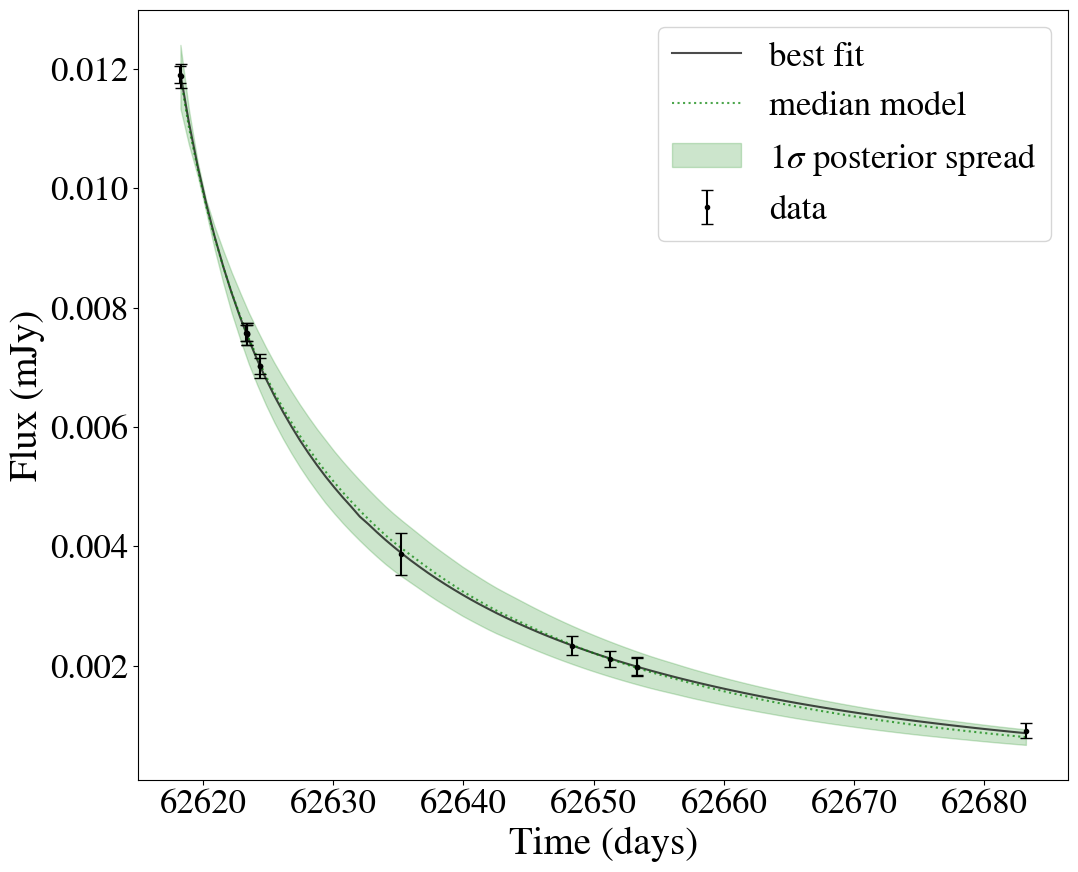

In [20]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(12,10))

t_fit = np.linspace(min(t), max(t), num=100)

# median model and spread in posteriors for 100 samples
med_model, spread = sample_walkers(30, samples, nu)

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

plt.plot(t_fit, best_fit_model, color="k", alpha=0.7, label='best fit')
plt.plot(t_fit, med_model, color="g", alpha=0.7, label='median model', ls=':')
plt.fill_between(t_fit, med_model - spread, med_model + spread, color="g", alpha=0.2,
                 label=r'$1\sigma$ posterior spread')

plt.errorbar(t, y, yerr=yerr, fmt=".k", capsize=4, label='data')

plt.xlabel('Time (days)', fontsize=28)
plt.ylabel('Flux (mJy)', fontsize=28)

plt.legend()

plt.show()

In [23]:
one_oa['config']

{'jetType': 4,
 'specType': 0,
 'b': 4,
 'thetaObs': np.float64(0.3484714326574438),
 'E0': np.float64(1.1888919316741776e+52),
 'thetaCore': np.float64(0.2480141947002742),
 'thetaWing': np.float64(1.0644141456480283),
 'n0': np.float64(0.08524611702634433),
 'p': 2.2,
 'epsilon_e': 0.1,
 'epsilon_B': 0.01,
 'xi_N': 1.0,
 'd_L': np.float64(1.2488755033518146e+27),
 'z': np.float64(0.08601737447284925)}

In [24]:
best_params

array([6.26100108e+04, 5.18943492e+01, 4.53891171e-01, 4.12418016e-01,
       4.99295741e-02])

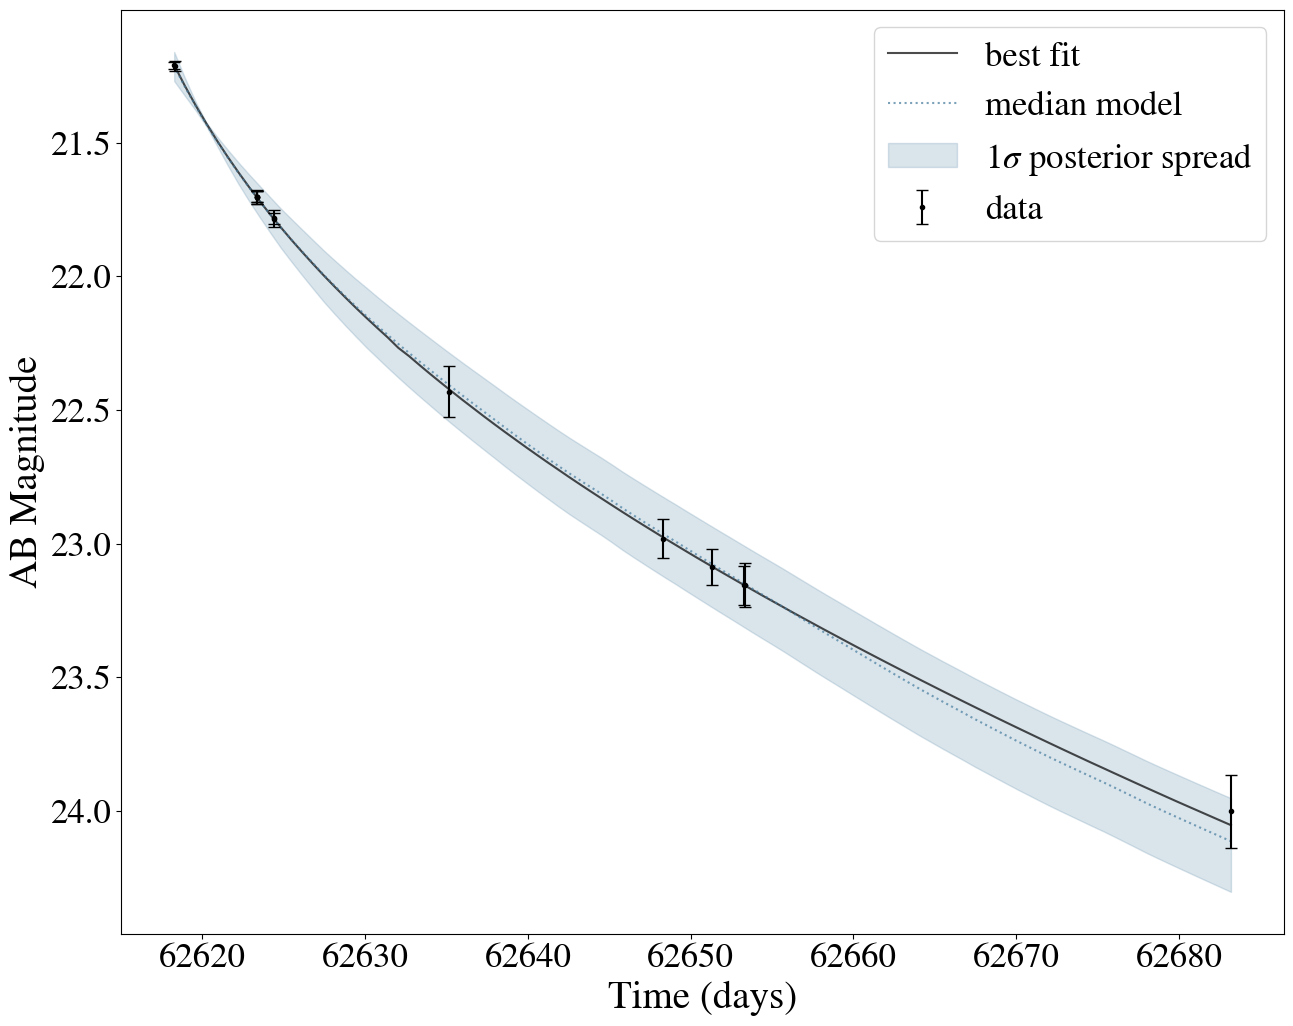

In [25]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(15,12))

t_fit = np.linspace(min(t), max(t), num=100)

# median model and spread in posteriors for 100 samples
med_model, spread = sample_walkers(30, samples, nu)

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

plt.plot(t_fit, flux_to_mag(best_fit_model), color="k", alpha=0.7, label='best fit')
plt.plot(t_fit, flux_to_mag(med_model), color="#457b9d", alpha=0.7, label='median model', ls=':')
plt.fill_between(t_fit, flux_to_mag(med_model - spread), flux_to_mag(med_model + spread), color="#457b9d", alpha=0.2,
                 label=r'$1\sigma$ posterior spread')

plt.errorbar(t, flux_to_mag(y), yerr=mags_err[mags < one_oa['mags_lim']], fmt=".k", capsize=4, label='data')

plt.xlabel('Time (days)', fontsize=28)
plt.ylabel('AB Magnitude', fontsize=28)
plt.gca().invert_yaxis()

plt.legend()
#plt.savefig('../figures/example_MCMC_orphan_fit.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

In [12]:
Time(oa[5]['grb_time']).mjd

62608.622838958334

In [43]:
best_params

array([ 6.26080411e+04,  5.19574318e+01,  4.71724931e-01,  3.40704245e-01,
        4.24120228e-01, -8.67232586e-02])

In [45]:
10**-8.67232586e-02

0.8189864969805426

In [26]:
names = ['T0', 'log10E0', 'thetaObs', 'thetaCore', 'thetaWing', 'log10n0']
labels = labels = ['T_0', r'log_{10}(E_0)', r'\theta_{obs}', r'\theta_c', r'\theta_w', r'log_{10}(n_0)']

settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_triangle = MCSamples(
    samples=samples,
    names=names,
    labels=labels,
    settings=settings
)

Removed no burn in


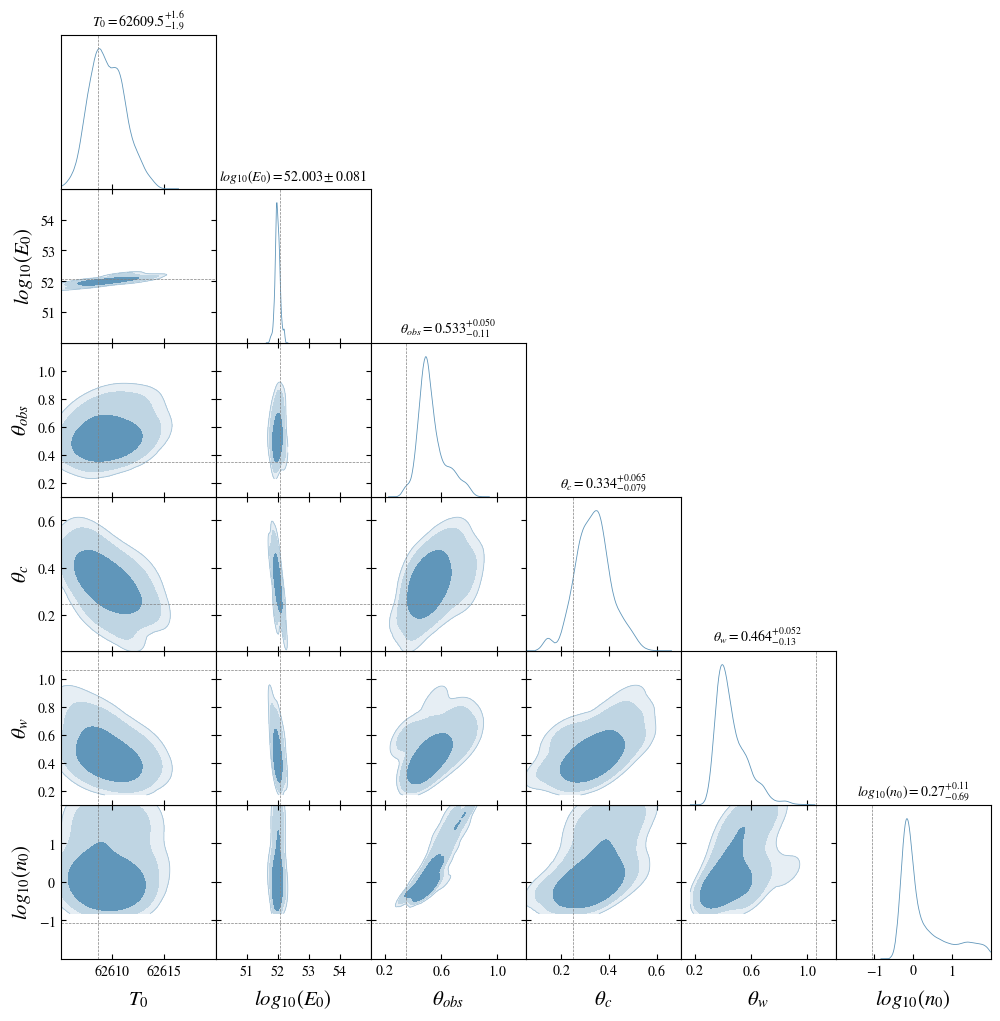

In [42]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.settings.axes_fontsize = 13 
g.settings.lab_fontsize = 18
g.settings.title_limit_fontsize = 13 
g.triangle_plot(samples_triangle, filled=True, contour_colors=['#6096ba'], title_limit=1,
                markers={'T0': Time(one_oa['grb_time']).mjd,
                         'log10E0': np.log10(one_oa['config']['E0']),
                         'thetaObs': one_oa['config']['thetaObs'],
                         'thetaCore': one_oa['config']['thetaCore'],
                         'thetaWing': one_oa['config']['thetaWing'],
                         'log10n0': np.log10(one_oa['config']['n0'])},
                param_limits={'T0': (62605, 62620),
                      'log10E0': (50,55),
                      'thetaObs': (0.1, 1.2),
                      'thetaCore': (0.05, 0.7),
                      'thetaWing': (0.1, 1.2),
                      'log10n0': (-2, 2)})

#plt.savefig('../figures/fit_triangle_plot.pdf', format="pdf", bbox_inches="tight", transparent=True)

/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


(-2.0, 2.0)

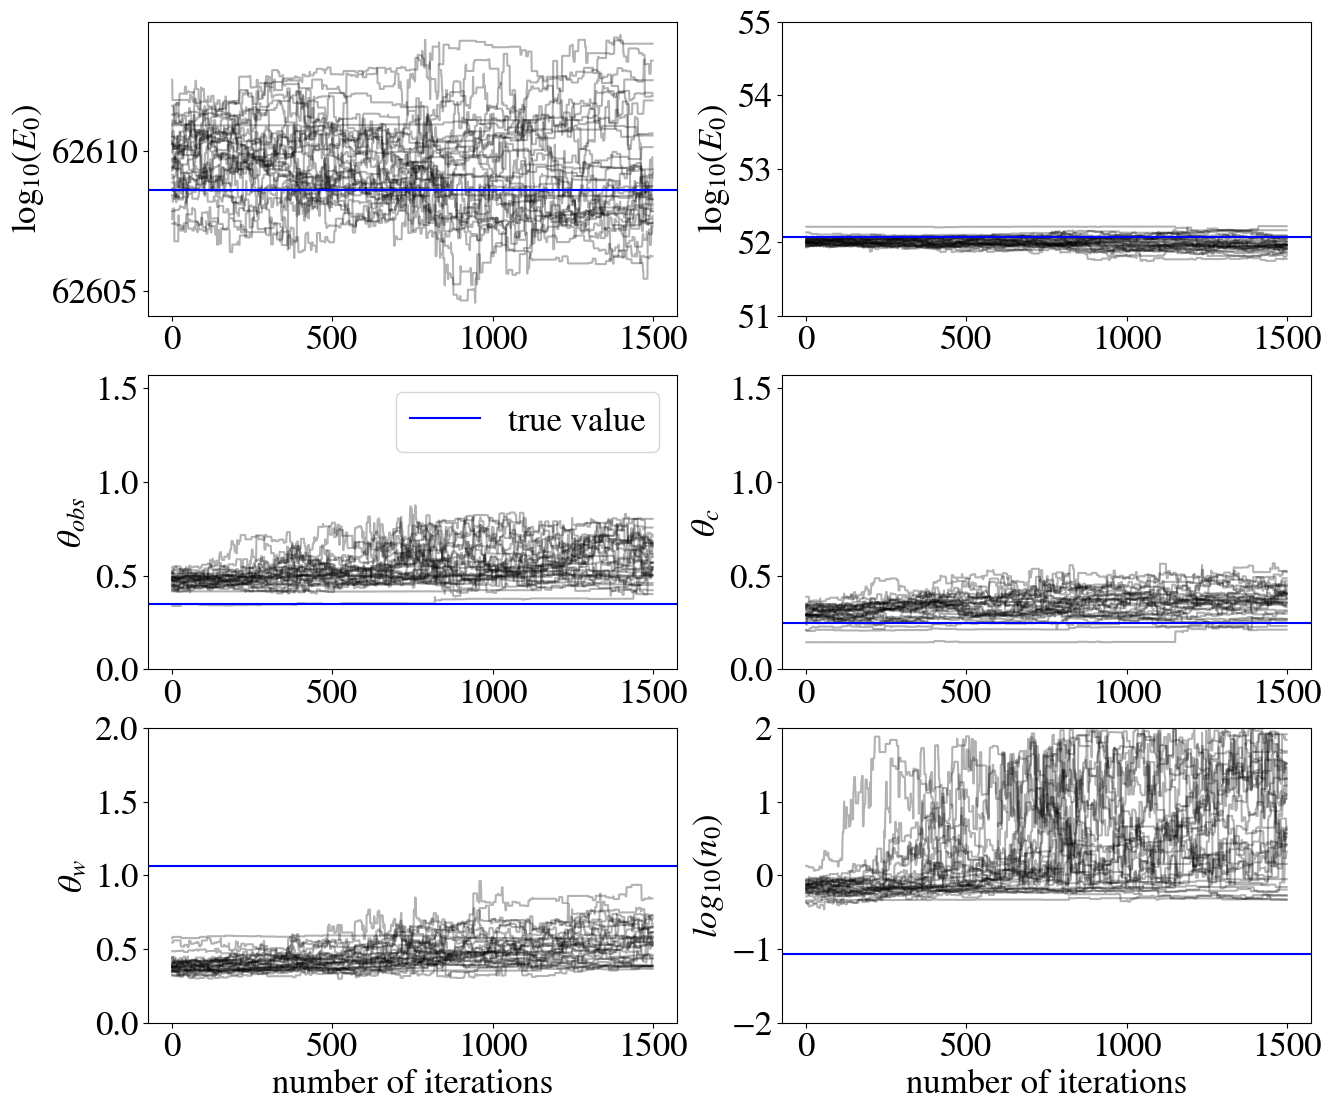

In [46]:
true_values = [Time(one_oa['grb_time']).mjd, np.log10(one_oa['config']['E0']), one_oa['config']['thetaObs'],
               one_oa['config']['thetaCore'], one_oa['config']['thetaWing'], 
               np.log10(one_oa['config']['n0'])]

fig, axes = plt.subplots(figsize=(15,13), nrows=3, ncols=2)

for i in range(ndim):
    
    ax = plt.subplot(3,2,i+1)
    plt.plot(sampler.chain[:,:,i].T, '-', color='k', alpha=0.3)
    plt.axhline(true_values[i], color='blue', label='true value')    

axes[0][0].set_ylabel(r'log$_{10}$($E_0$)')
#axes[0][0].set_ylim(51, 55)

axes[0][1].set_ylabel(r'log$_{10}$($E_0$)')
axes[0][1].set_ylim(51, 55)

axes[1][0].set_ylabel(r'$\theta_{obs}$')
axes[1][0].set_ylim(0., np.pi/2)
axes[1][0].legend()

axes[1][1].set_ylabel(r'$\theta_c$')
axes[1][1].set_ylim(0., np.pi/2)

axes[2][0].set_ylabel(r'$\theta_w$')
axes[2][0].set_xlabel('number of iterations')
axes[2][0].set_ylim(0, 2)

axes[2][1].set_ylabel(r'$log_{10}(n_0)$')
axes[2][1].set_xlabel('number of iterations')
axes[2][1].set_ylim(-2, 2)

#axes[2][1].axis('off')